In [ ]:
# only if current working directory is not ../AcceleratedPathPatching
import os

os.chdir("/mnt/lustre/home/eickhoff/esx670/AcceleratedPathPatching")

%load_ext autoreload
%autoreload 2

['', 'mnt', 'lustre', 'home', 'eickhoff', 'esx670', 'AcceleratedPathPatching', 'Patching']


In [34]:
import gc
import numpy as np

import torch
import networkx as nx
import huggingface_hub
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import einops
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from utils.data_io import create_folder, set_PATH

from utils.parser import parser
from utils.data_io import get_base_path

from utils.data_io import create_folder

In [36]:

torch.cuda.empty_cache()
gc.collect()

#################### Parser #####################################

is_notebook = get_ipython()
ipython =  is_notebook is not None

if ipython:
    input_args = [
        # ----- models ------
        #'--model_name=gpt2-large',
        #"--model_name=Qwen/Qwen2.5-7B",
        #"--model_name=Qwen/Qwen2.5-0.5B",
        '--model_name=gpt2',
        '--device=cuda',

        # ------ dataset arguments --------           
        '--seed=12345432',
        '--N=10',  
        '--batch_size=10',
        '--metric=logits_diff',
        #'--patch_mlp',
        
        # ----- tasks ------
        #'--task=GreaterThan',
        #'--task=IOI',
        #'--task=GenderedPronouns',
        '--task=Induction',
        #"--task=Docstring",
        
        # ----- Acceleration arguments ------
        "--do_accelerate",

        # ----- FLAP arguments -----
        '--lowest_sparsity=60', 
        '--highest_sparsity=100', 
        '--cliff_point_list', 'first', 'biggest', 'fixed',
        '--step_size=1',
        
        # ----- ACDC arguments -----
        "--num_threshold=1", 
        "--abs_value_threshold",
        "--patch_mlp",
        
        # ----- I/O arguments -----
        '--save_every_x_steps=100',
        "--out_path=/mnt/lustre/work/eickhoff/esx670/res_final/",
        "--cache_dir=/mnt/lustre/work/eickhoff/esx670/llm_weights/",

        
        #"--save_img",
        #"--show",
        "--verbose",
        #"--save_text", 
        #"--calc_FLOP"
    ]
args = parser.parse_args(input_args)


# Setting seeds for reproducibility

np.random.seed(args.seed)
torch.random.manual_seed(args.seed)

set_PATH(args.out_path)

/mnt/lustre/work/eickhoff/esx670/res_final//gpt2/Induction/path/automatic/maxVal-0.002/importance-3.0/
load gpt2 as CasualLLM adapted to the Llama architecture


GPT2Model2Llama has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.
INFO:shared_logger:Splitting and mapping: transformer.h.0.attn.c_attn.weight -> QKV weights for layer 0
INFO:shared_logger:Splitting and mapping: transformer.h.0.attn.c

load gpt2 tokenizer
Loading Induction Dataset with gpt2


Processing layers: 100%|██████████| 12/12 [00:00<00:00, 92.86it/s]


Loading Induction Dataset with gpt2


...

Processing layers: 100%|██████████| 12/12 [00:00<00:00, 95.04it/s]


Loading Induction Dataset with gpt2


Processing layers: 100%|██████████| 12/12 [00:00<00:00, 48.63it/s]
/mnt/lustre/home/eickhoff/esx670/AcceleratedPathPatching/utils/visualization.py:641: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([0, 1.0, 0.8, 0.6, 0.4, 0.2, 0.0] )


load gpt2 tokenizer
loading gpt2 as HookedTransformer
use float 16
Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  cuda
Loading Induction Dataset with gpt2


/mnt/lustre/home/eickhoff/esx670/AcceleratedPathPatching/Evaluation/findBestCircuit.py:291: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_results = pd.concat([df_results, new_row],  ignore_index=True)
/mnt/lustre/home/eickhoff/esx670/AcceleratedPathPatching/Evaluation/findBestCircuit.py:85: RuntimeWarning: invalid value encountered in divide
  signed_distances.append(cross / v_norm)


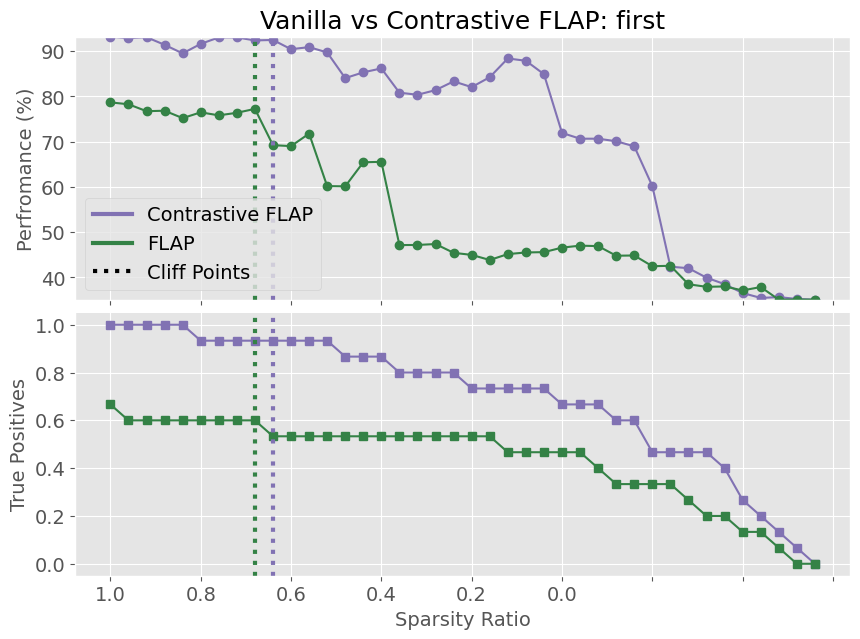

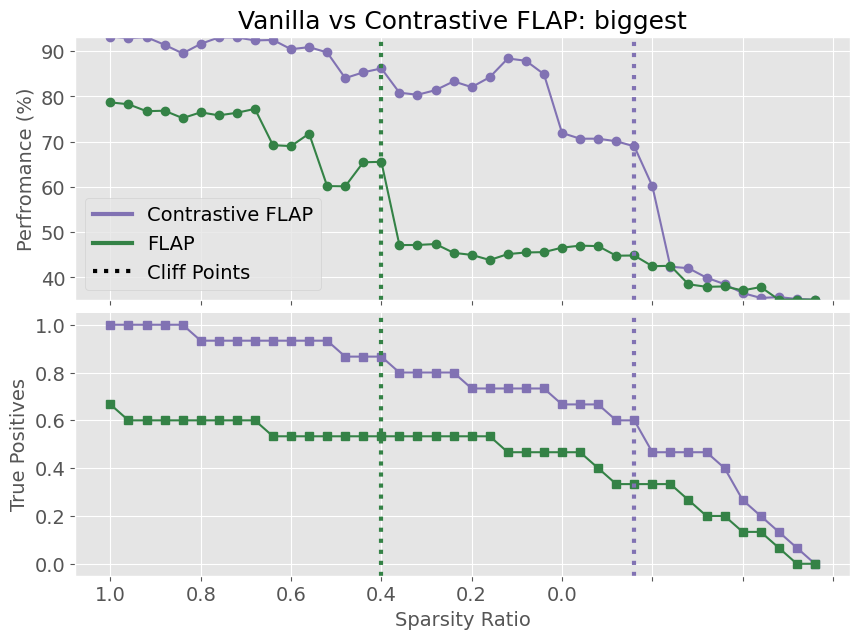

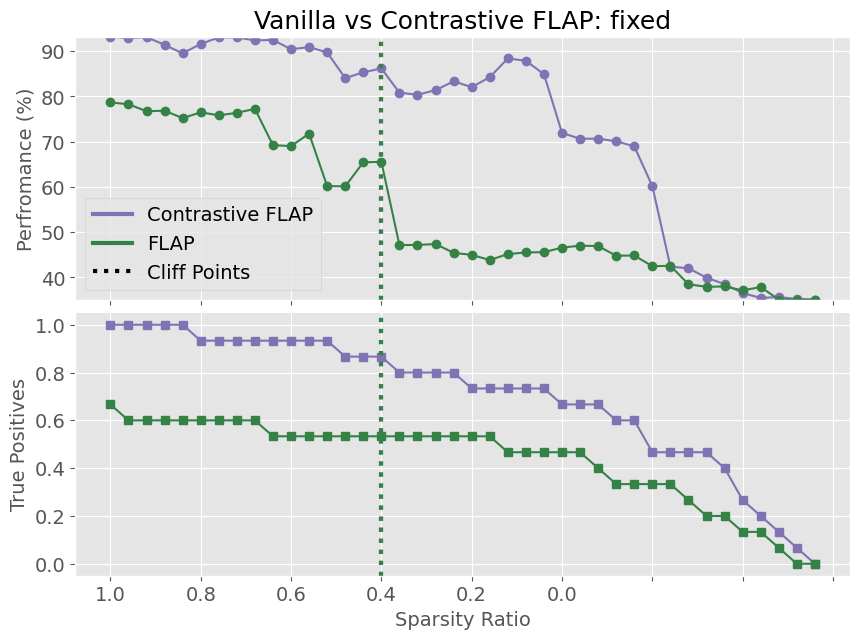

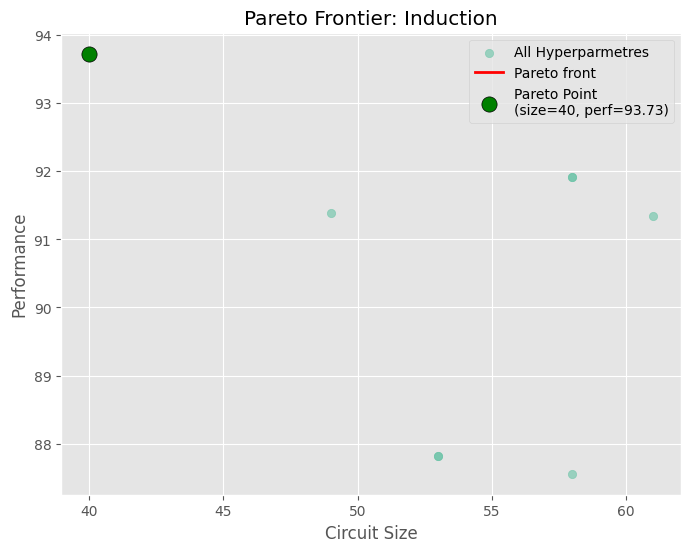

In [40]:
from Pruning.FLAP.lib.main import get_hybrid_FLAP_CIRCUIT

HYBRID_FLAP_CIRCUIT = get_hybrid_FLAP_CIRCUIT(args)

In [42]:
HYBRID_FLAP_CIRCUIT.get(0)

{1, 5, 11}

loading gpt2 as HookedTransformer
use float 16
Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  cuda
load gpt2 tokenizer
Loading Induction Dataset with gpt2
/mnt/lustre/work/eickhoff/esx670/res_final//gpt2/Induction/acceleratedACDC//0.5/logits_diff_N-10/


dict_keys(['blocks.11.hook_resid_post', 'blocks.11.hook_mlp_out', 'blocks.11.hook_mlp_in', 'blocks.11.attn.hook_result', 'blocks.11.attn.hook_q', 'blocks.11.hook_q_input', 'blocks.11.attn.hook_k', 'blocks.11.hook_k_input', 'blocks.11.attn.hook_v', 'blocks.11.hook_v_input', 'blocks.10.hook_mlp_out', 'blocks.10.hook_mlp_in', 'blocks.10.attn.hook_result', 'blocks.10.attn.hook_q', 'blocks.10.hook_q_input', 'blocks.10.attn.hook_k', 'blocks.10.hook_k_input', 'blocks.10.attn.hook_v', 'blocks.10.hook_v_input', 'blocks.9.hook_mlp_out', 'blocks.9.hook_mlp_in', 'blocks.9.attn.hook_result', 'blocks.9.attn.hook_q', 'blocks.9.hook_q_input', 'blocks.9.attn.hook_k', 'blocks.9.hook_k_input', 'blocks.9.attn.hook_v', 'blocks.9.hook_v_input', 'blocks.8.hook_mlp_out', 'blocks.8.hook_mlp_in', 'blocks.8.attn.hook_result', 'blocks.8.attn.hook_q', 'blocks.8.hook_q_input', 'blocks.8.attn.hook_k', 'blocks.8.hook_k_input', 'blocks.8.attn.hook_v', 'blocks.8.hook_v_input', 'blocks.7.hook_mlp_out', 'blocks.7.hook_ml

/mnt/lustre/home/eickhoff/esx670/AcceleratedPathPatching/Patching/acdc/TLACDCExperiment.py:871: UserWarning: Finished iterating
  


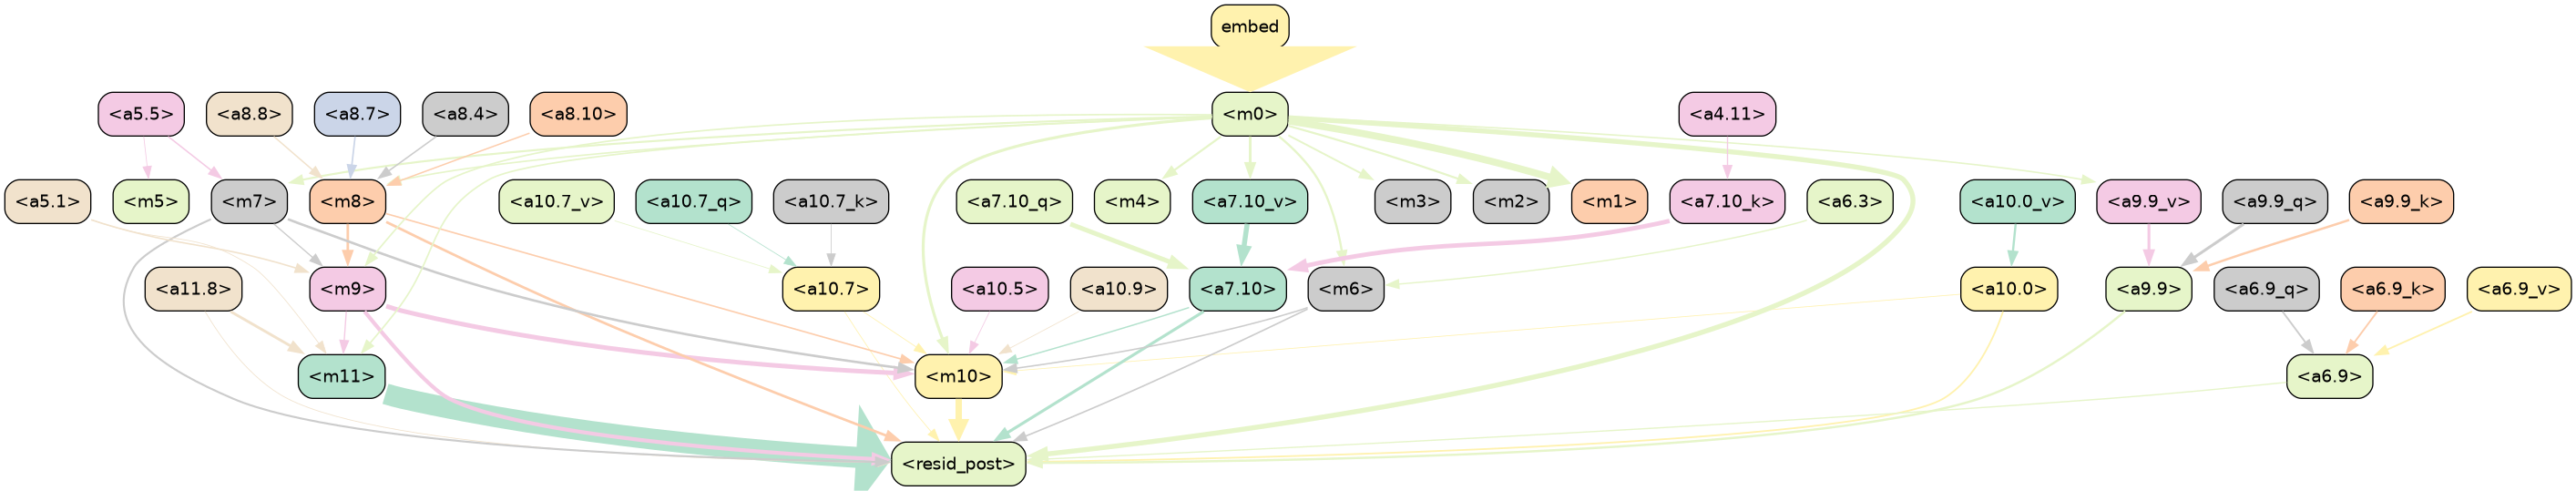

DataFrame saved as efficency_metrics.json at /mnt/lustre/work/eickhoff/esx670/res_final//gpt2/Induction/acceleratedACDC//0.5/logits_diff_N-10/


{0.5: {11: [8],
  10: [9, 7, 5, 0],
  9: [9],
  8: [10, 8, 7, 4],
  7: [10],
  6: [9, 3],
  5: [5, 1],
  4: [11]}}

In [39]:
from Patching.ACDC import run_acdc

run_acdc(args, HYBRID_FLAP_CIRCUIT, threshold_values=[0.5])